<a href="https://colab.research.google.com/github/padmasri2005/DataScience-Tasks/blob/main/Task_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analysing Ecommerce sales drop**

**Company Scenario (Flipkart/amazon) :**

we are seeing a drop in revenue find the reason and suggest actions

In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# data loading
customers = pd.read_csv("/content/customers.csv")
orders = pd.read_csv("/content/orders.csv")
products = pd.read_csv("/content/products.csv")

#merging

In [ ]:
orders

,order_id,customer_id,product_id,order_date,city,quantity
0,1,101,201,2024-01-05,Hyderabad,1
1,2,102,202,2024-01-06,Bangalore,2
2,3,103,203,2024-01-10,Chennai,1
3,4,101,202,2024-02-12,Hyderabad,1
4,5,104,204,2024-02-18,Bangalore,3
5,6,105,201,2024-03-05,Chennai,1
6,7,102,203,2024-03-15,Bangalore,1
7,8,106,205,2024-04-02,Hyderabad,2
8,9,107,202,2024-04-10,Chennai,1
9,10,108,204,2024-04-18,Bangalore,2


In [ ]:
customers

,customer_id,customer_name,signup_date
0,101,Ravi,2023-11-10
1,102,Sneha,2023-12-01
2,103,Amit,2023-12-15
3,104,Pooja,2024-01-05
4,105,Kiran,2024-01-20
5,106,Arjun,2024-02-02
6,107,Divya,2024-02-15
7,108,Rahul,2024-03-01
8,109,Meena,2024-03-10
9,110,Vikram,2024-04-01


In [ ]:
df = pd.merge(customers,orders,on = "customer_id",how = "inner")
df = pd.merge(df,products,on = "product_id",how = "inner")

# EDA
(Explorartory Data Analysis)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    20 non-null     int64 
 1   customer_name  20 non-null     object
 2   signup_date    20 non-null     object
 3   order_id       20 non-null     int64 
 4   product_id     20 non-null     int64 
 5   order_date     20 non-null     object
 6   city           20 non-null     object
 7   quantity       20 non-null     int64 
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [ ]:
# converting object data type to date datatype
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['order_date'] = pd.to_datetime(df['order_date'])


In [ ]:
# creating the revenue col
df['revenue'] = df['price']*df['quantity']

In [ ]:
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000,9000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000,70000


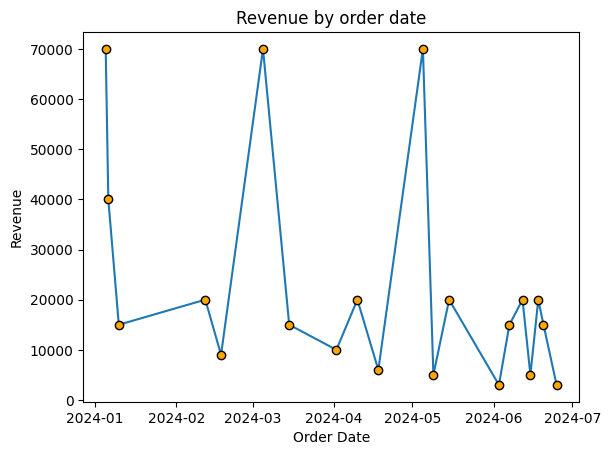

In [ ]:
# revenue trend by order_date
revenue = df.groupby("order_date")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue['order_date'],revenue['revenue'],marker = "o",mfc = "orange",mec = "black")
plt.xlabel("Order Date")
plt.ylabel("Revenue")
plt.title("Revenue by order date")
plt.show()

From the above graph
the **revenue is very less in the last two month (june and july)**

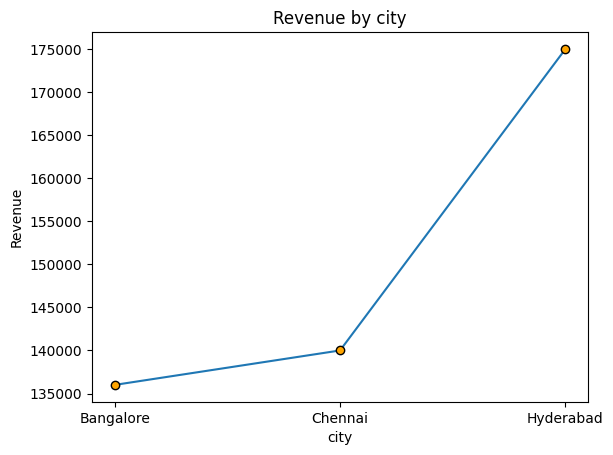

In [ ]:
df["city"].unique()

# revenue trend by city
revenue = df.groupby("city")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue['city'],revenue['revenue'],marker = "o",mfc = "orange",mec = "black")
plt.xlabel("city")
plt.ylabel("Revenue")
plt.title("Revenue by city")
plt.show()


**Revenue is droping in banglore**

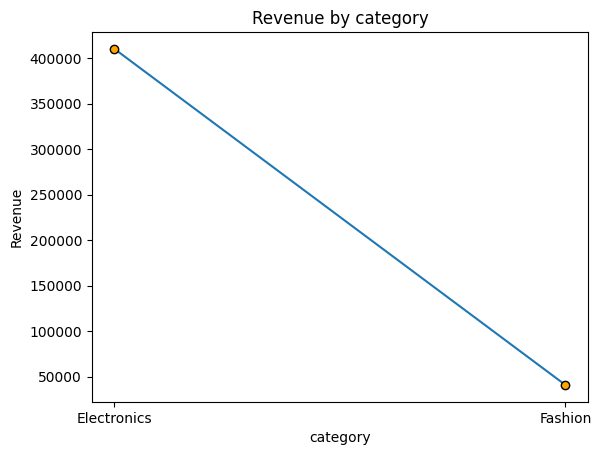

In [ ]:
df["category"].unique()

# revenue trend by city
revenue = df.groupby("category")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue['category'],revenue['revenue'],marker = "o",mfc = "orange",mec = "black")
plt.xlabel("category")
plt.ylabel("Revenue")
plt.title("Revenue by category")
plt.show()

**In fashion category revenue got dropped**

In [ ]:
# count customers based on order id -- (count of order per customers)
# df["customer_id"].count()

df.groupby('customer_id')['order_id'].count()


,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


**Most of the customers are ordering less**

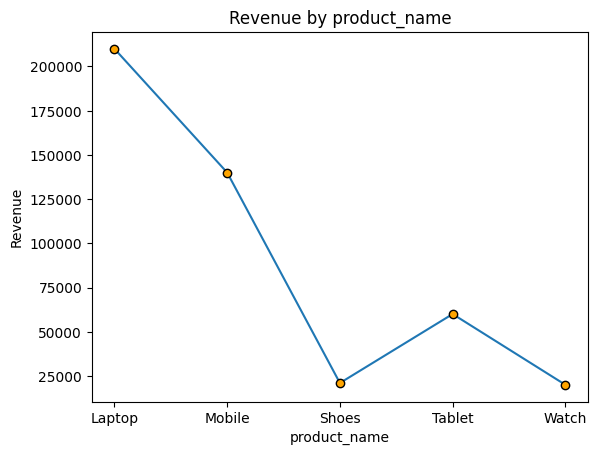

In [ ]:
# product_name
df["product_name"].unique()

# revenue trend by product_name
revenue = df.groupby("product_name")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue['product_name'],revenue['revenue'],marker = "o",mfc = "orange",mec = "black")
plt.xlabel("product_name")
plt.ylabel("Revenue")
plt.title("Revenue by product_name")
plt.show()

**Revenue is very less for shoes and watch**

# Insights:


1.   Revenue got dropped in the last two months(jun,jul)
2.   Banglore contributed more in revenue drop
3.   Fashion category recorded less revenue
4.   Repeated customers ordered less
5.   Shoe and watch sales declined significantly


# Recommendations:


1.   Marketing should be done in banglore
2.   Provide discounts on shoe and watch
3.   coupens,discounts,loyalty programs for repeated customers

